In [1]:
!pip -q install ompl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.4/28.4 MB 37.7 MB/s eta 0:00:00


In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

from ompl import base as ob
from ompl import geometric as og

Solved: Exact solution
Geometric path with 7 states
Compound state [
RealVectorState [1 1]
SO2State [0]
]
Compound state [
RealVectorState [1.69511 2.44322]
SO2State [-0.00481104]
]
Compound state [
RealVectorState [2.26398 4.42195]
SO2State [-0.159267]
]
Compound state [
RealVectorState [3.90065 5.66727]
SO2State [-0.077412]
]
Compound state [
RealVectorState [5.13395 6.84498]
SO2State [-0.102483]
]
Compound state [
RealVectorState [7.17722 8.14277]
SO2State [-0.236002]
]
Compound state [
RealVectorState [9 9]
SO2State [0]
]




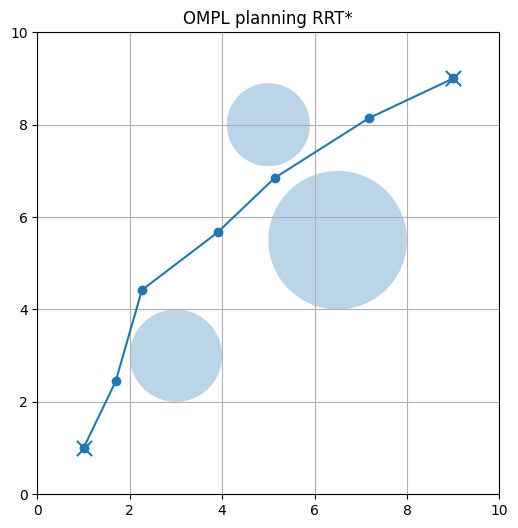

In [34]:
# --------- 1) Define state space: SE(2) = (x, y, yaw) ----------
space = ob.SE2StateSpace()

# Bounds for x,y
bounds = ob.RealVectorBounds(2)
bounds.setLow(0, 0.0)   # x low
bounds.setLow(1, 0.0)   # y low
bounds.setHigh(0, 10.0) # x high
bounds.setHigh(1, 10.0) # y high
space.setBounds(bounds)

# --------- 2) Create SimpleSetup ----------
ss = og.SimpleSetup(space)

# --------- 3) Obstacles (circles) + validity checker ----------
obstacles = [
    (3.0, 3.0, 1.0),
    (6.5, 5.5, 1.5),
    (5.0, 8.0, 0.9),
]

def is_state_valid(state: ob.State) -> bool:
    x = state.getX()
    y = state.getY()
    if x < 0 or x > 10 or y < 0 or y > 10:
        return False
    for ox, oy, r in obstacles:
        if (x - ox)**2 + (y - oy)**2 <= r**2:
            return False
    return True

ss.setStateValidityChecker(ob.StateValidityCheckerFn(is_state_valid))

# --------- 4) Start / Goal ----------
start = ob.State(space)
start().setX(1.0)
start().setY(1.0)
start().setYaw(0.0)

goal = ob.State(space)
goal().setX(9.0)
goal().setY(9.0)
goal().setYaw(0.0)

ss.setStartAndGoalStates(start, goal)

# --------- 5) Choose a planner ----------
planner = og.RRTstar(ss.getSpaceInformation())
planner.setRange(2.5)
ss.setPlanner(planner)

# finer checking resolution along edges
ss.getSpaceInformation().setStateValidityCheckingResolution(0.01)

# --------- 6) Solve ----------
solved = ss.solve(2.0)  # seconds

print("Solved:", solved)

if solved:
    #ss.simplifySolution()
    path = ss.getSolutionPath()
    print(path)

    # --------- 7) Extract path points for plotting ----------
    states = path.getStates()
    xs = [s.getX() for s in states]
    ys = [s.getY() for s in states]

    # --------- 8) Plot ----------
    fig, ax = plt.subplots(figsize=(6, 6))

    # obstacles
    for ox, oy, r in obstacles:
        circ = plt.Circle((ox, oy), r, fill=True, alpha=0.3)
        ax.add_patch(circ)

    # path
    ax.plot(xs, ys, marker="o")
    ax.scatter([start().getX(), goal().getX()],
               [start().getY(), goal().getY()],
               marker="x", s=120)

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_aspect("equal", "box")
    ax.set_title("OMPL planning RRT*")
    ax.grid(True)
    plt.show()
else:
    print("No solution found. Try increasing solve time or adjusting obstacles.")

In [35]:
print("range =", planner.getRange())

range = 2.5
